In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

Products, Categories aur Sub-Categories ki performance analyze karna.

# Business ko pata chalega:

1. Kaunsa product sabse zyada bikta hai.

2. Kaunsa product sabse zyada profit deta hai.

3. Kaunsa product loss me hai.

4. Kaunsi category best perform kar rahi hai.

5. Kaunsi category ko improve karna chahiye.

In [68]:
df = pd.read_csv(
    "../data/processed/featured_superstore.csv",
    parse_dates=["Order Date", "Ship Date"]
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,Year,Month,Month Name,Quarter,Day Name,Shipping Days,Profit Margin,Discount Category
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.9136,2016,11,November,4,Tuesday,3,16.00,No Discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.5820,2016,11,November,4,Tuesday,3,30.00,No Discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.8714,2016,6,June,2,Sunday,4,47.00,No Discount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.0310,2015,10,October,4,Sunday,7,-40.00,Medium Discount
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.5164,2015,10,October,4,Sunday,7,11.25,Low Discount


# 1️⃣Top 10 Products by Sales
Which products generated the highest sales?

In [69]:
top10_products  = (df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10).reset_index())
top10_products 

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


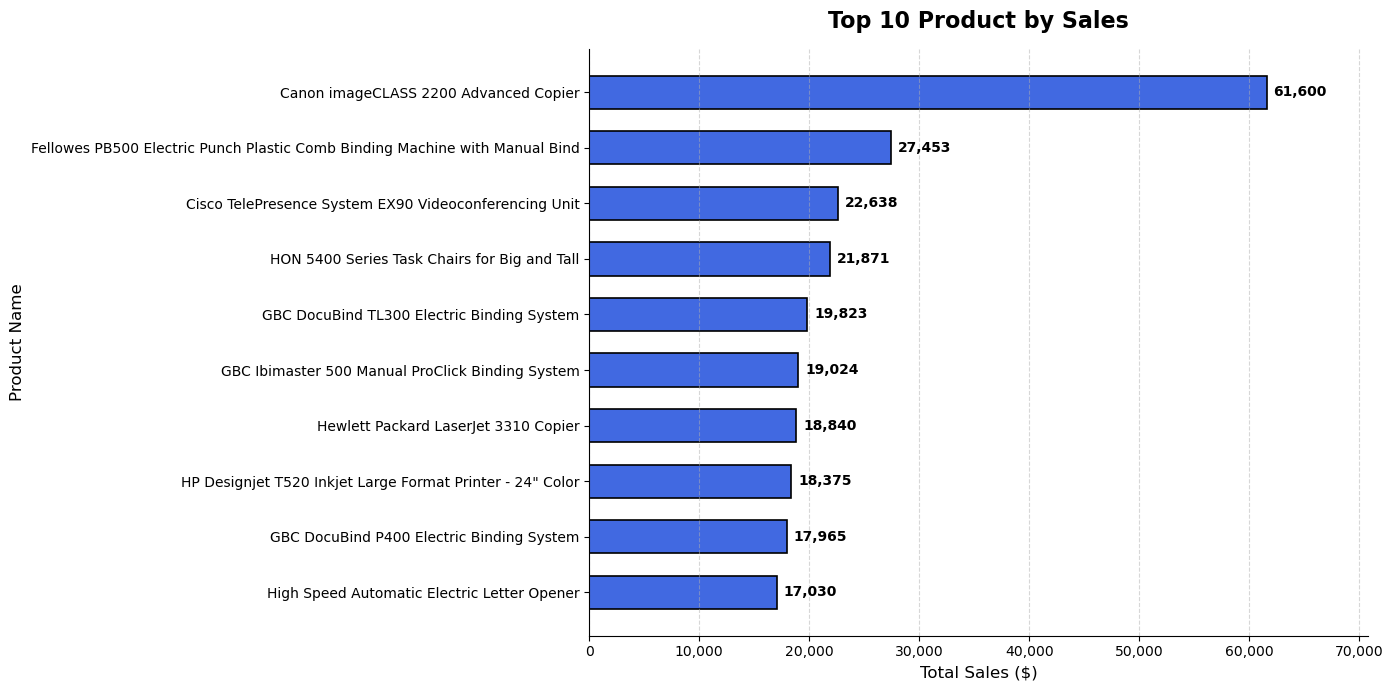

In [70]:
plt.figure(figsize=(14,7))

bars = plt.barh(top10_products["Product Name"], top10_products["Sales"],
         color="royalblue", edgecolor="black", linewidth=1.2, height=0.6
)

plt.gca().invert_yaxis()

plt.title("Top 10 Product by Sales", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Sales ($)", fontsize=12)

plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

plt.xlim(0, top10_products["Sales"].max() * 1.15)

plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)


offset = top10_products["Sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/top10_products_sales.png",
    dpi=300, bbox_inches="tight"
)

plt.show()

## Business Insight

A small number of products contribute a significant portion of total sales. Identifying these top-performing products helps the business focus on inventory planning, marketing efforts, and demand forecasting.

## Business Recommendation

- Maintain sufficient inventory for top-selling products.
- Prioritize marketing campaigns for high-performing products.
- Bundle top-selling products with low-selling products to improve overall sales.
- Continuously monitor product demand to avoid stock shortages.

# 2️⃣Top 10 Products by Profit
Which products generated the highest profit?

In [71]:
top10_products_by_profit  = (df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10).reset_index())
top10_products_by_profit 

,Product Name,Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


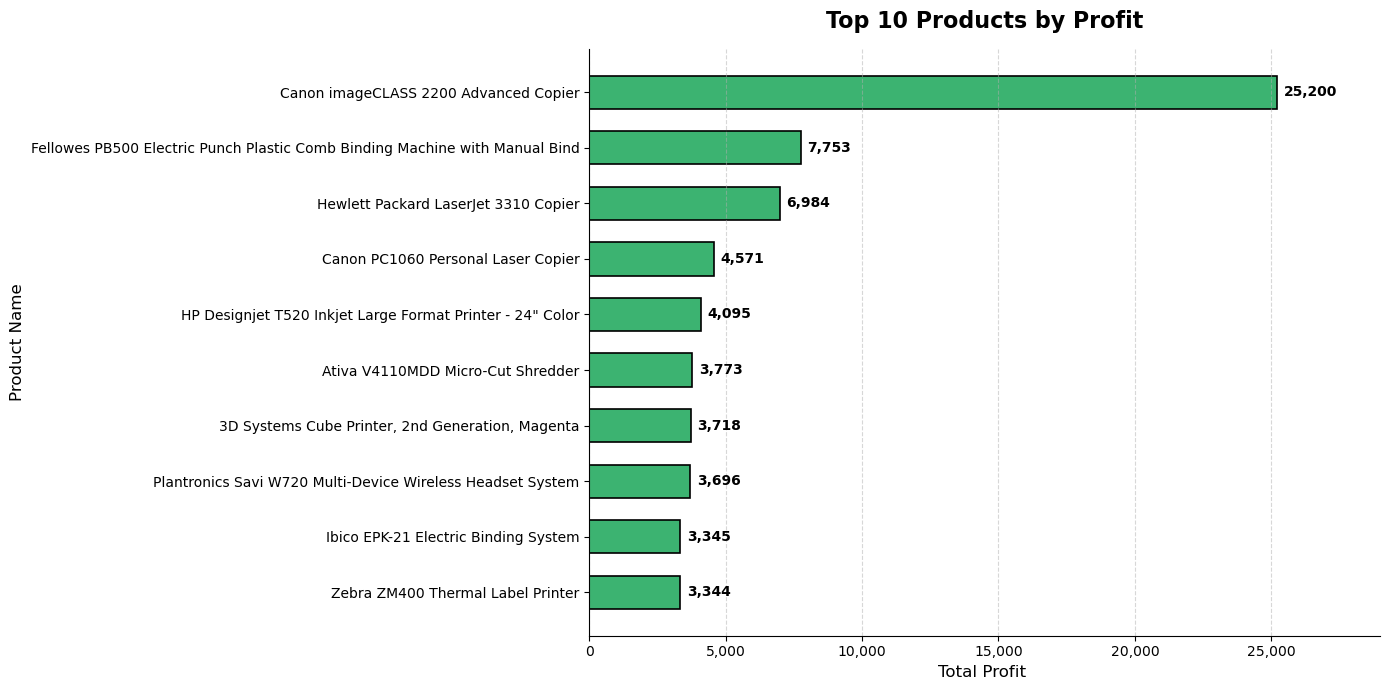

In [72]:

plt.figure(figsize=(14,7))

bars = plt.barh(top10_products_by_profit["Product Name"], top10_products_by_profit["Profit"],
         color="mediumseagreen", edgecolor="black", linewidth=1.2, height=0.6
)

plt.gca().invert_yaxis()

plt.title("Top 10 Products by Profit", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Profit ", fontsize=12)

plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

plt.xlim(0, top10_products_by_profit["Profit"].max() * 1.15)

# Format x-axis values
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)


offset = top10_products_by_profit["Profit"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/top10_products_profit.png",
    dpi=300, bbox_inches="tight"
)

plt.show()

## Business Insight

A small number of products generate most of the company's profit. These products are the key contributors to overall business profitability.

## Business Recommendation

- Keep these products in stock.
- Promote them through marketing campaigns.
- Focus on increasing their sales to maximize profit.

# 3️⃣ Top 10 Loss-Making Products
Which products generated the highest losses?

In [73]:
top10_products_loss = (df.groupby("Product Name")["Profit"].sum().sort_values(ascending=True).head(10).reset_index())
top10_products_loss

,Product Name,Profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
4,Bush Advantage Collection Racetrack Conference...,-1934.3976
5,GBC DocuBind P400 Electric Binding System,-1878.1662
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836
8,Balt Solid Wood Round Tables,-1201.0581
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375


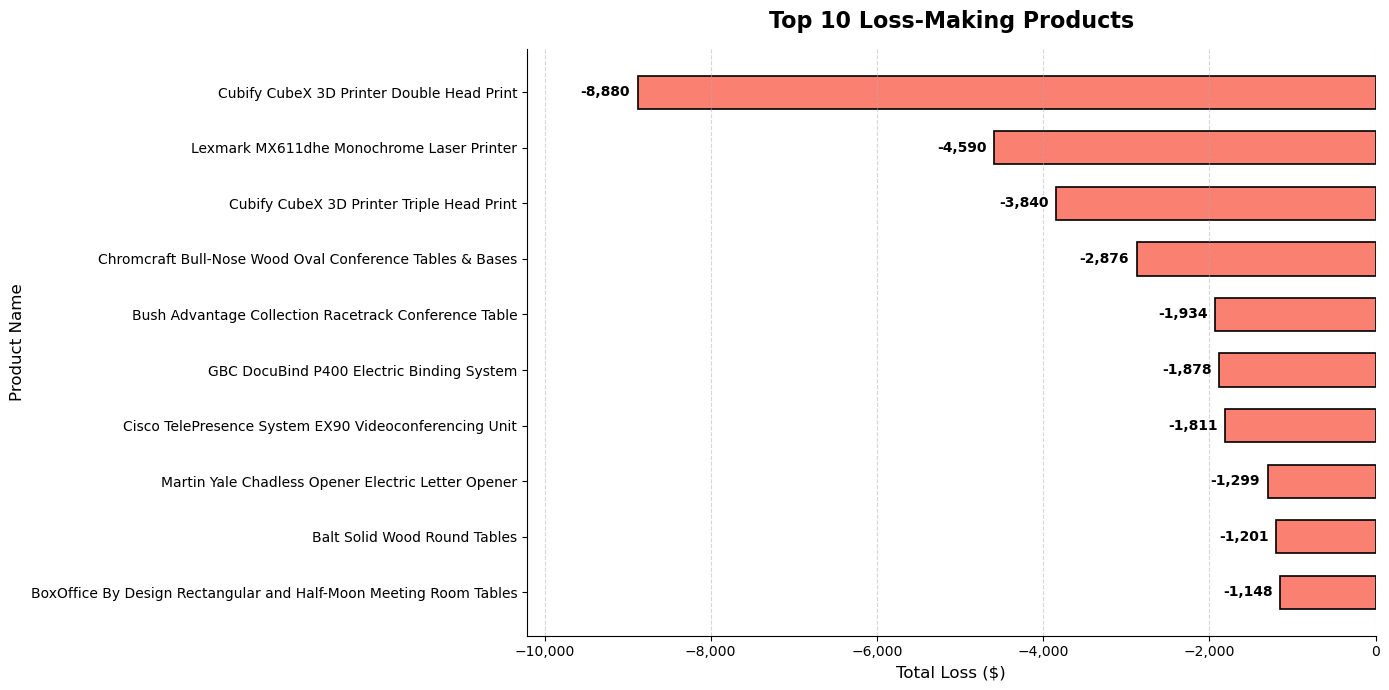

In [82]:
plt.figure(figsize=(14,7))

bars = plt.barh(top10_products_loss["Product Name"], top10_products_loss["Profit"],
                color="salmon", edgecolor="black", linewidth=1.2, height=0.6
)

# Highest loss at the top
plt.gca().invert_yaxis()

plt.title("Top 10 Loss-Making Products", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Loss ($)", fontsize=12)

plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--",alpha=0.5)

plt.yticks(fontsize=10)

# Negative x-axis
plt.xlim(top10_products_loss["Profit"].min() * 1.15, 0)

# Format x-axis values
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

offset = abs(top10_products_loss["Profit"].min()) * 0.01

for bar in bars:
    plt.text(
        bar.get_width() - offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="right",
        fontsize=10, fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/top10_loss_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

A few products generate the highest losses and reduce overall business profitability.

## Business Recommendation

- Review pricing and discount strategies.
- Reduce operational costs for these products.
- Improve or discontinue consistently loss-making products.

# Average Sales per Product
Which products generate the highest average sales per order?

In [92]:
avg_sale_per_product = (df.groupby("Product Name")["Sales"].mean().sort_values(ascending=False).head(10).reset_index())
avg_sale_per_product

,Product Name,Sales
0,Cisco TelePresence System EX90 Videoconferenci...,22638.480000
1,Canon imageCLASS 2200 Advanced Copier,12319.964800
2,Cubify CubeX 3D Printer Triple Head Print,7999.980000
3,"3D Systems Cube Printer, 2nd Generation, Magenta",7149.945000
4,HP Designjet T520 Inkjet Large Format Printer ...,6124.965000
5,High Speed Automatic Electric Letter Opener,5676.770667
6,Ibico EPK-21 Electric Binding System,5291.972000
7,Lexmark MX611dhe Monochrome Laser Printer,4207.475250
8,Canon imageCLASS MF7460 Monochrome Digital Las...,3991.980000
9,Okidata MB760 Printer,3917.200000


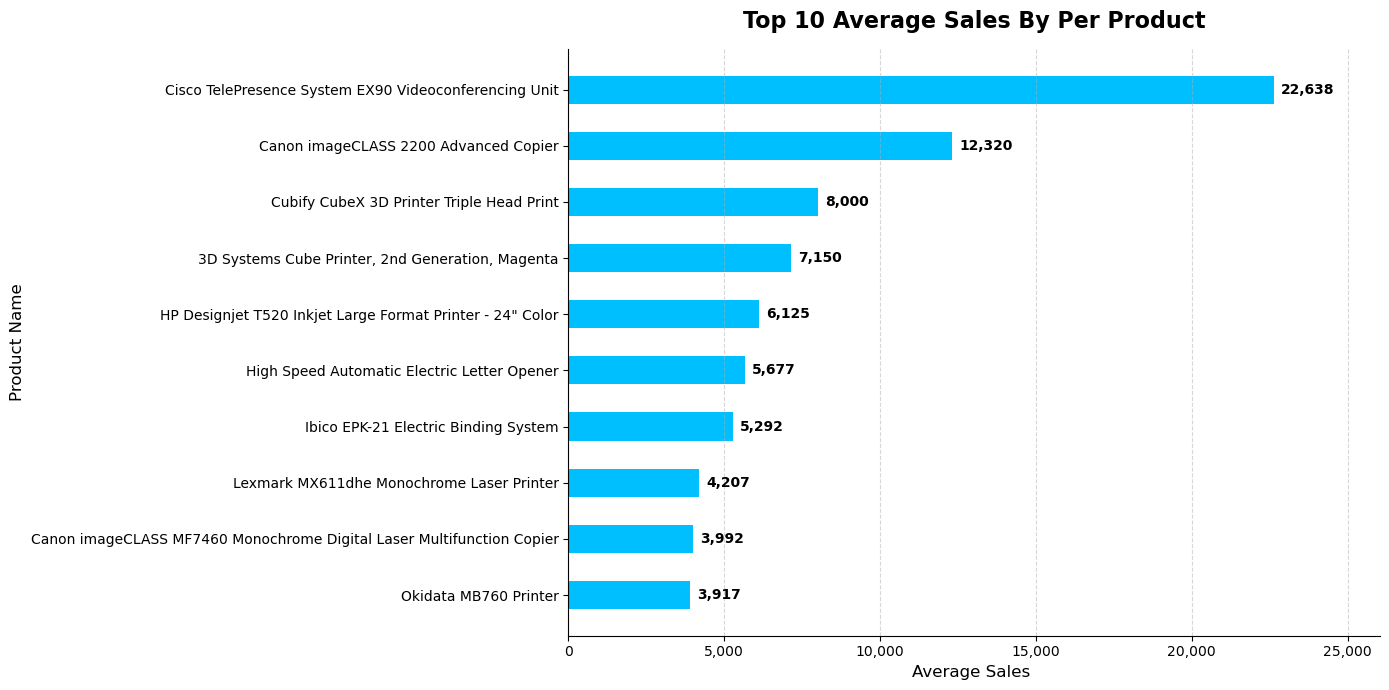

In [109]:
plt.figure(figsize=(14,7))

bars = plt.barh(avg_sale_per_product["Product Name"], avg_sale_per_product["Sales"],
                color="deepskyblue", linewidth=1.2, height=0.5
)

plt.gca().invert_yaxis()

plt.title("Top 10 Average Sales By Per Product", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Average Sales ", fontsize=12)

plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

plt.xlim(0, avg_sale_per_product["Sales"].max() * 1.15)

# Format x-axis values
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

offset = avg_sale_per_product["Sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )
    

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/avg_sales_by_product.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()